# MovieLens: EDA + рекомендации (ALS)

Источник: Hive `pysparktest.movies`, `pysparktest.ratings` (DAG `movielens_postgres_to_hive`).

Если ошибка `rating: Expected: double, Found: INT32` — один раз перезапишите Parquet и DDL:

```bash
docker exec spark_dataspell_container python3 /home/jovyan/work/jdbc_movielens_to_hdfs.py
docker exec hive-server bash /scripts/register-movielens-tables.sh
```

**Kernel → Restart** и **Run All**.

После обучения — деплой в MLflow (`movielens_recommendations`, serve http://localhost:5004).

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.sql import functions as F

from hive_ddl_utils import (
    create_hive_spark_session,
    read_movielens_hive,
    wait_hive_ports,
)

In [2]:
wait_hive_ports()
spark = create_hive_spark_session(app_name="movielens-recommend")

movies, ratings = read_movielens_hive(spark)

n_movies = movies.count()
n_ratings = ratings.count()
print(f"movies: {n_movies:,}, ratings: {n_ratings:,}")
movies.show(3, truncate=60)
ratings.show(3)

Ожидание metastore hive-metastore:9083 ...
  metastore доступен.
Ожидание hiveserver2 hive-server:10000 ...
  hiveserver2 доступен.


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/29 18:16:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


=== Hive: pysparktest.movies, pysparktest.ratings ===


movies: 9,742, ratings: 100,836
+-------+-----------------------+-------------------------------------------+
|movieId|                  title|                                     genres|
+-------+-----------------------+-------------------------------------------+
|      1|       Toy Story (1995)|Adventure|Animation|Children|Comedy|Fantasy|
|      2|         Jumanji (1995)|                 Adventure|Children|Fantasy|
|      3|Grumpier Old Men (1995)|                             Comedy|Romance|
+-------+-----------------------+-------------------------------------------+
only showing top 3 rows

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
+------+-------+------+---------+
only showing top 3 rows



## EDA

In [3]:
n_users = ratings.select("userId").distinct().count()
rating_stats = ratings.agg(
    F.min("rating").alias("min"),
    F.max("rating").alias("max"),
    F.avg("rating").alias("avg"),
    F.stddev("rating").alias("std"),
).collect()[0]

possible = n_users * n_movies
density = 100.0 * n_ratings / possible if possible else 0.0
avg_per_user = n_ratings / n_users if n_users else 0.0

print("=== Summary ===")
print(f"  users:           {n_users:,}")
print(f"  movies:          {n_movies:,}")
print(f"  ratings:         {n_ratings:,}")
print(f"  matrix density:  {density:.4f}%")
print(f"  ratings / user:  {avg_per_user:.1f}")
print(
    f"  rating: min={rating_stats.min}, max={rating_stats.max}, "
    f"avg={rating_stats.avg:.3f}, std={float(rating_stats.std or 0):.3f}"
)

ratings_per_user = ratings.groupBy("userId").count()
user_cnt_stats = ratings_per_user.agg(
    F.min("count").alias("min"),
    F.max("count").alias("max"),
    F.avg("count").alias("avg"),
).collect()[0]
print(
    f"  ratings per user: min={user_cnt_stats.min}, max={user_cnt_stats.max}, "
    f"avg={user_cnt_stats.avg:.1f}"
)

=== Summary ===
  users:           610
  movies:          9,742
  ratings:         100,836
  matrix density:  1.6968%
  ratings / user:  165.3
  rating: min=0.5, max=5.0, avg=3.502, std=1.043
  ratings per user: min=20, max=2698, avg=165.3


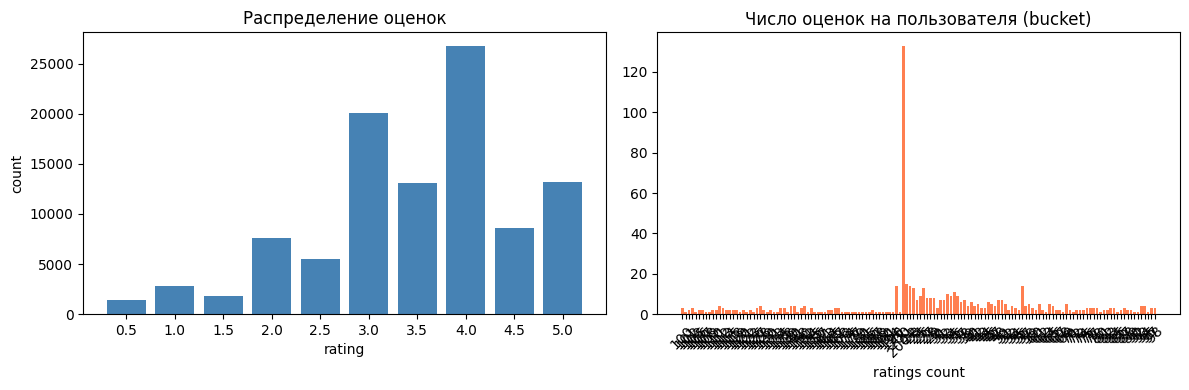

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_pdf = ratings.groupBy("rating").count().orderBy("rating").toPandas()
axes[0].bar(rating_pdf["rating"].astype(str), rating_pdf["count"], color="steelblue")
axes[0].set_title("Распределение оценок")
axes[0].set_xlabel("rating")
axes[0].set_ylabel("count")

user_hist = ratings_per_user.select(
    F.when(F.col("count") > 200, F.lit("200+")).otherwise(F.col("count").cast("string")).alias("bucket"),
).groupBy("bucket").count().orderBy("bucket").toPandas()
axes[1].bar(user_hist["bucket"], user_hist["count"], color="coral")
axes[1].set_title("Число оценок на пользователя (bucket)")
axes[1].set_xlabel("ratings count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

=== Top-10 фильмов по числу оценок ===
+-------+-----------------------------------------+---------+-----------------+
|movieId|                                    title|n_ratings|       avg_rating|
+-------+-----------------------------------------+---------+-----------------+
|    356|                      Forrest Gump (1994)|      329|4.164133738601824|
|    318|         Shawshank Redemption, The (1994)|      317|4.429022082018927|
|    296|                      Pulp Fiction (1994)|      307|4.197068403908795|
|    593|         Silence of the Lambs, The (1991)|      279|4.161290322580645|
|   2571|                       Matrix, The (1999)|      278|4.192446043165468|
|    260|Star Wars: Episode IV - A New Hope (1977)|      251|4.231075697211155|
|    480|                     Jurassic Park (1993)|      238|             3.75|
|    110|                        Braveheart (1995)|      237|4.031645569620253|
|    589|        Terminator 2: Judgment Day (1991)|      224|3.970982142857143|
|

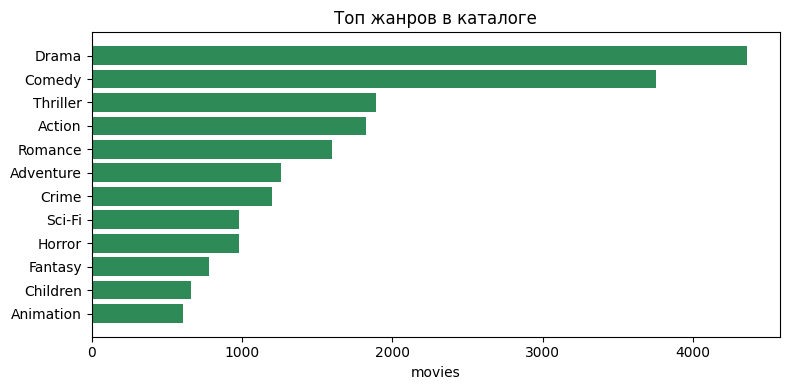

In [5]:
top_movies = (
    ratings.groupBy("movieId")
    .agg(F.count("*").alias("n_ratings"), F.avg("rating").alias("avg_rating"))
    .join(movies, "movieId")
    .orderBy(F.desc("n_ratings"))
    .limit(10)
)
print("=== Top-10 фильмов по числу оценок ===")
top_movies.select("movieId", "title", "n_ratings", "avg_rating").show(10, truncate=50)

genre_rows = (
    movies.withColumn("genre", F.explode(F.split("genres", "\\|")))
    .groupBy("genre")
    .count()
    .orderBy(F.desc("count"))
    .limit(12)
    .toPandas()
)
plt.figure(figsize=(8, 4))
plt.barh(genre_rows["genre"][::-1], genre_rows["count"][::-1], color="seagreen")
plt.title("Топ жанров в каталоге")
plt.xlabel("movies")
plt.tight_layout()
plt.show()

## Обучение ALS (collaborative filtering)

Разбиение **по времени**: последние 20% оценок каждого пользователя — test (ближе к реальному сценарию).

In [6]:
from pyspark.sql import Window

w = Window.partitionBy("userId").orderBy(F.col("timestamp").asc())
ranked = ratings.withColumn("rn", F.row_number().over(w)).withColumn(
    "n_user", F.count("*").over(Window.partitionBy("userId"))
)
test_cutoff = (F.col("n_user") * 0.8).cast("int")

train = ranked.filter(F.col("rn") <= F.greatest(test_cutoff, F.lit(1))).select(
    "userId", "movieId", "rating", "timestamp"
)
test = ranked.filter(F.col("rn") > F.greatest(test_cutoff, F.lit(1))).select(
    "userId", "movieId", "rating", "timestamp"
)

train = train.cache()
test = test.cache()
print(f"train: {train.count():,}, test: {test.count():,}")

train: 80,419, test: 20,417


In [7]:
als = ALS(
    rank=16,
    maxIter=12,
    regParam=0.1,
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    seed=42,
)

print("Обучение ALS...")
model = als.fit(train)
print("Готово.")

Обучение ALS...


26/05/29 18:17:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/29 18:17:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Готово.


## Метрики качества

**Регрессия** (насколько точно предсказывается оценка): RMSE, MAE, R².

**Ранжирование** (насколько хорошо модель находит фильмы из test в топ-K): Precision@K, Recall@K, MAP@K, coverage каталога.

In [11]:
from pyspark.sql import Window


def regression_metrics(predictions_df):
    """RMSE, MAE, R² на парах (rating, prediction)."""
    pred = predictions_df.filter(F.col("prediction").isNotNull())
    rmse = RegressionEvaluator(
        metricName="rmse", labelCol="rating", predictionCol="prediction"
    ).evaluate(pred)
    mae = RegressionEvaluator(
        metricName="mae", labelCol="rating", predictionCol="prediction"
    ).evaluate(pred)
    r2 = RegressionEvaluator(
        metricName="r2", labelCol="rating", predictionCol="prediction"
    ).evaluate(pred)
    n = pred.count()
    return {"rmse": rmse, "mae": mae, "r2": r2, "n_predictions": n}


def ranking_metrics_at_k(
    model,
    train_df,
    test_df,
    *,
    k: int = 10,
    candidates: int = 80,
):
    """Precision@K, Recall@K, MAP@K: test-фильмы vs топ-K рекомендаций (без train)."""
    train_seen = train_df.groupBy("userId").agg(
        F.collect_set("movieId").alias("seen_movies")
    )
    test_users = test_df.groupBy("userId").agg(
        F.collect_set("movieId").alias("relevant_movies"),
        F.count("*").alias("n_relevant"),
    )

    recs_raw = model.recommendForUserSubset(
        test_users.select("userId"), max(k, candidates)
    )
    recs = (
        recs_raw.select("userId", F.explode("recommendations").alias("rec"))
        .select(
            "userId",
            F.col("rec.movieId").alias("movieId"),
            F.col("rec.rating").alias("score"),
        )
        .join(train_seen, "userId")
        .filter(~F.array_contains(F.col("seen_movies"), F.col("movieId")))
    )

    w = Window.partitionBy("userId").orderBy(F.desc("score"))
    topk = (
        recs.withColumn("rank", F.row_number().over(w))
        .filter(F.col("rank") <= k)
        .join(test_users, "userId")
        .withColumn(
            "is_hit",
            F.array_contains(F.col("relevant_movies"), F.col("movieId")),
        )
    )

    per_user = topk.groupBy("userId", "n_relevant").agg(
        F.sum(F.when(F.col("is_hit"), 1).otherwise(0)).alias("hits_at_k"),
    )
    agg = per_user.agg(
        F.avg(F.col("hits_at_k") / F.lit(float(k))).alias("precision_at_k"),
        F.avg(F.col("hits_at_k") / F.col("n_relevant")).alias("recall_at_k"),
        F.sum(F.when(F.col("hits_at_k") > 0, 1).otherwise(0)).alias("users_with_hit"),
        F.count("*").alias("n_users"),
    ).collect()[0]

    w_cum = (
        Window.partitionBy("userId")
        .orderBy("rank")
        .rowsBetween(Window.unboundedPreceding, Window.currentRow)
    )
    ap_rows = (
        topk.withColumn(
            "cum_hits",
            F.sum(F.when(F.col("is_hit"), 1).otherwise(0)).over(w_cum),
        )
        .filter(F.col("is_hit"))
        .withColumn("prec_at_rank", F.col("cum_hits") / F.col("rank"))
    )
    map_at_k = ap_rows.groupBy("userId").agg(
        F.avg("prec_at_rank").alias("ap")
    ).agg(F.avg("ap").alias("map_at_k")).collect()[0][0]

    catalog_cov = (
        topk.select("movieId").distinct().count() / float(n_movies)
        if n_movies
        else 0.0
    )

    return {
        "precision_at_k": float(agg.precision_at_k),
        "recall_at_k": float(agg.recall_at_k),
        "map_at_k": float(map_at_k) if map_at_k is not None else float("nan"),
        "user_hit_rate": float(agg.users_with_hit) / float(agg.n_users),
        "catalog_coverage": catalog_cov,
        "k": k,
    }


# --- регрессия на test ---
predictions = model.transform(test)
reg = regression_metrics(predictions)

print("=== Регрессия (test) ===")
print(f"  RMSE:          {reg['rmse']:.4f}")
print(f"  MAE:           {reg['mae']:.4f}")
print(f"  R²:            {reg['r2']:.4f}")
print(f"  предсказаний:  {reg['n_predictions']:,}")

# --- ранжирование @K ---
print("\n=== Ранжирование (среднее по пользователям из test) ===")
metrics_rank: dict[int, dict] = {}
for k in (5, 10):
    rk = ranking_metrics_at_k(model, train, test, k=k, candidates=100)
    metrics_rank[k] = rk
    print(f"  K={k}:")
    print(f"    Precision@{k}: {rk['precision_at_k']:.4f}")
    print(f"    Recall@{k}:    {rk['recall_at_k']:.4f}")
    print(f"    MAP@{k}:       {rk['map_at_k']:.4f}")
    print(f"    User hit rate: {rk['user_hit_rate']:.4f}")
    print(f"    Catalog cov.:  {rk['catalog_coverage']:.4f}")

predictions.select("userId", "movieId", "rating", "prediction").show(5)

=== Регрессия (test) ===
  RMSE:          0.9231
  MAE:           0.7141
  R²:            0.2365
  предсказаний:  18,715

=== Ранжирование (среднее по пользователям из test) ===


  K=5:
    Precision@5: 0.0052
    Recall@5:    0.0011
    MAP@5:       0.3490
    User hit rate: 0.0262
    Catalog cov.:  0.0403


  K=10:
    Precision@10: 0.0064
    Recall@10:    0.0025
    MAP@10:       0.2429
    User hit rate: 0.0541
    Catalog cov.:  0.0651
+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|     2|  80906|   5.0| 3.2672262|
|     2|  89774|   5.0| 3.0469081|
|     2|   1704|   4.5| 3.7153153|
|     2| 122882|   5.0|  3.586749|
|     2|  80489|   4.5|  3.564202|
+------+-------+------+----------+
only showing top 5 rows



## MLflow: лог, Registry, serve

1. Ячейка ниже — `deploy_movielens_als_to_mlflow` (метрики + pyfunc с факторами ALS).
2. UI: http://localhost:5000 → experiment `movielens_recommendations` → Models → `movielens-als`.
3. Serve: http://localhost:5004 — после деплоя:
   `docker compose up -d mlflow-serve-movielens --force-recreate`

In [ ]:
import importlib
import sys

import mlflow_utils as mu

if "mlflow_utils" in sys.modules:
    mu = importlib.reload(mu)

from mlflow_utils import (
    MOVIELENS_EXPERIMENT,
    MOVIELENS_REGISTERED_MODEL_NAME,
    deploy_movielens_als_to_mlflow,
    mlflow_ui_url,
    movielens_serve_host_url,
    predict_movielens_via_serve,
)

als_params = {
    "rank": als.getRank(),
    "maxIter": als.getMaxIter(),
    "regParam": als.getRegParam(),
    "coldStartStrategy": als.getColdStartStrategy(),
    "nonnegative": als.getNonnegative(),
    "seed": als.getSeed(),
    "test_split": "time_20pct_per_user",
}

mlflow_metrics = {
    "test_rmse": reg["rmse"],
    "test_mae": reg["mae"],
    "test_r2": reg["r2"],
    "n_train": float(train.count()),
    "n_test": float(test.count()),
}
for k, rk in metrics_rank.items():
    mlflow_metrics[f"precision_at_{k}"] = rk["precision_at_k"]
    mlflow_metrics[f"recall_at_{k}"] = rk["recall_at_k"]
    mlflow_metrics[f"map_at_{k}"] = rk["map_at_k"]
    mlflow_metrics[f"user_hit_rate_at_{k}"] = rk["user_hit_rate"]
    mlflow_metrics[f"catalog_coverage_at_{k}"] = rk["catalog_coverage"]

run_id = deploy_movielens_als_to_mlflow(
    model,
    metrics=mlflow_metrics,
    params=als_params,
    experiment_name=MOVIELENS_EXPERIMENT,
    model_name=MOVIELENS_REGISTERED_MODEL_NAME,
    target_stage="Production",
)

print(f"MLflow UI: {mlflow_ui_url()} → Models → {MOVIELENS_REGISTERED_MODEL_NAME}")
print(f"run_id: {run_id}")
print(f"После recreate serve: {movielens_serve_host_url()}")

### Проверка MLflow serve

Требуется запущенный `mlflow-serve-movielens` (порт **5004**).

In [ ]:
import json

serve_user = 42
serve_k = 10
payload = predict_movielens_via_serve([serve_user], k=serve_k)
print(json.dumps(payload, indent=2, ensure_ascii=False)[:2000])

if isinstance(payload, list) and payload:
    recs_serve = payload[0].get("recommendations", [])
    if recs_serve:
        ids = [r["movieId"] for r in recs_serve]
        spark.createDataFrame([(i,) for i in ids], ["movieId"]).join(
            movies, "movieId"
        ).select("movieId", "title", "genres").show(serve_k, truncate=45)

## Пример рекомендаций

In [12]:
SAMPLE_USER = 42
TOP_N = 10

seen = set(
    r.movieId
    for r in ratings.filter(F.col("userId") == SAMPLE_USER).select("movieId").collect()
)

user_subset = spark.createDataFrame([(SAMPLE_USER,)], ["userId"])
recs = model.recommendForUserSubset(user_subset, TOP_N + len(seen))

rec_rows = recs.collect()[0]["recommendations"]
rec_filtered = [r for r in rec_rows if r.movieId not in seen][:TOP_N]

rec_df = spark.createDataFrame(
    [(r.movieId, float(r.rating)) for r in rec_filtered],
    ["movieId", "pred_score"],
).join(movies, "movieId")

print(f"Пользователь {SAMPLE_USER}: уже оценил {len(seen)} фильмов")
print(f"Топ-{TOP_N} рекомендаций (ALS):")
rec_df.select("movieId", "title", "genres", "pred_score").show(TOP_N, truncate=45)

Пользователь 42: уже оценил 440 фильмов
Топ-10 рекомендаций (ALS):
+-------+---------------------------------------------+-----------------+-----------------+
|movieId|                                        title|           genres|       pred_score|
+-------+---------------------------------------------+-----------------+-----------------+
| 177593|Three Billboards Outside Ebbing, Missouri ...|      Crime|Drama| 5.23723030090332|
| 112804|                             I Origins (2014)|     Drama|Sci-Fi|5.082704067230225|
|   3925|                Stranger Than Paradise (1984)|     Comedy|Drama|  5.0754075050354|
|  51931|                         Reign Over Me (2007)|            Drama|4.996619701385498|
|  47423|                           Half Nelson (2006)|            Drama|4.911743640899658|
| 141718|                             Deathgasm (2015)|    Comedy|Horror|4.846334457397461|
| 117531|                             Watermark (2014)|      Documentary|4.840646743774414|
|  86237|    

In [10]:
train.unpersist()
test.unpersist()
# spark.stop()  # раскомментируйте, если нужно освободить память

DataFrame[userId: int, movieId: int, rating: double, timestamp: bigint]